
# Forecasting ChatGPT Popularity and User Engagement Using ARIMA, SARIMA, and LSTM Models

### Project Objectives
- Analyze the growth and popularity of ChatGPT over time.
- Study trends, seasonality, and user engagement behavior.
- Forecast future popularity using statistical and deep learning forecasting models.
- Compare classical forecasting methods with deep learning methods.

---

## Introduction

### Large Language Models (LLMs)
Large Language Models (LLMs) are advanced artificial intelligence systems trained on massive text datasets to understand and generate human-like language. These models utilize deep learning architectures, particularly transformer networks, to perform tasks such as text generation, summarization, translation, coding assistance, and conversational AI.

### ChatGPT and AI Adoption
ChatGPT, developed by OpenAI, is one of the most widely adopted AI applications globally. The platform has transformed how users interact with AI by providing intelligent conversational capabilities across education, business, software development, and research.

### Importance of Forecasting ChatGPT Popularity
Forecasting user engagement and popularity trends helps organizations:
- Understand AI adoption patterns.
- Predict future demand.
- Optimize infrastructure and scalability.
- Improve customer experience.
- Support strategic decision-making.

### Time Series Forecasting in AI Analytics
Time series forecasting is widely used in predictive analytics to model sequential data over time. In this project, we use:
- ARIMA
- SARIMA
- LSTM Neural Networks

to forecast ChatGPT popularity and compare statistical methods with deep learning approaches.


Import Required Libraries


In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use('fivethirtyeight')
from scipy import stats
import pylab
import math
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.special import boxcox, inv_boxcox
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Input, LSTM, Dense, Dropout
from keras.models import Model, Sequential
from tensorflow.keras.utils import plot_model
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

import warnings
warnings.filterwarnings('ignore')


## Data Understanding & Preprocessing

In [19]:


df = pd.read_csv("/content/chatgpt_reviews.csv", on_bad_lines='skip', encoding='latin1')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1022544, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,ace4af50-2f1f-4bb2-af96-3463336c9c3c,Bharath Bharath bb,â¤ï¸â¤ï¸,5,0,1.2026.111,2026-05-06 09:42:15,1.2026.111
1,e67ad4c2-c145-494d-a05b-67f1f44f417e,Snoopy Kubsad,"too good, chat gpt hadn't disappointed me as g...",5,0,NaN,2026-05-06 09:41:29,NaN
2,018a3395-8e39-4741-86bd-37a20179f589,Sukhwinder Kaur,chat gpt was great,5,0,1.2026.111,2026-05-06 09:41:26,1.2026.111
3,2e0c8038-f1b2-4cd3-8da9-287f9b58118e,faruk adamu lanko,Outstanding app,5,0,1.2025.154,2026-05-06 09:41:22,1.2025.154
4,78ccb278-a691-4a72-9581-e7912f57c29f,Mahesh Khavadiya,amazing ð¤©,5,0,1.2026.111,2026-05-06 09:39:15,1.2026.111


In [20]:


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1022544 entries, 0 to 1022543
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   reviewId              1022544 non-null  object
 1   userName              1022542 non-null  object
 2   content               1022528 non-null  object
 3   score                 1022544 non-null  int64 
 4   thumbsUpCount         1022544 non-null  int64 
 5   reviewCreatedVersion  947768 non-null   object
 6   at                    1022544 non-null  object
 7   appVersion            947768 non-null   object
dtypes: int64(2), object(6)
memory usage: 62.4+ MB


Checking for Missing Values




In [21]:
df.isnull().sum()

,0
reviewId,0
userName,2
content,16
score,0
thumbsUpCount,0
reviewCreatedVersion,74776
at,0
appVersion,74776


Check for duplicated rows in the dataset




In [22]:

df.duplicated().sum()

np.int64(2509)

Get a statistical summary of the dataset

In [23]:

df.describe()

,score,thumbsUpCount
count,1.022544e+06,1.022544e+06
mean,4.488428e+00,1.582220e-01
std,1.116509e+00,2.214637e+01
min,1.000000e+00,0.000000e+00
25%,5.000000e+00,0.000000e+00
50%,5.000000e+00,0.000000e+00
75%,5.000000e+00,0.000000e+00
max,5.000000e+00,2.067900e+04


Check the shape (number of rows and columns) of the dataset

In [24]:

df.shape

(1022544, 8)

Time Series Data Preprocessing

In [25]:

df['at'] = pd.to_datetime(df['at'], errors='coerce', format='mixed')


df = df.sort_values('at')


df = df.drop_duplicates()


df = df.dropna(subset=['at'])


df['date'] = df['at'].dt.date
df['date'] = pd.to_datetime(df['date'])

df.head()


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,date
976046,1558c5f6-90b3-468c-856b-428e353758a4,Free fire Hiphop id (BORN4GOD),What type this app,4,3,1.0.0016,2023-07-25 15:01:35,1.0.0016,2023-07-25
976586,96d93138-1b82-42b2-bc38-e7d7aee59527,MD Noman Hossen,I am the first one ðð,5,3,NaN,2023-07-25 15:01:54,NaN,2023-07-25
1018365,e69568f3-b2ec-4f89-afc1-6d09646a8f21,Sohan happy boy,Bahut Achcha work,5,2,1.0.0016,2023-07-25 15:02:58,1.0.0016,2023-07-25
965931,9c08eb11-cfb6-4023-bb2a-7fdceef094fb,Mohammed Ismail,Pretty good UI,4,0,1.0.0016,2023-07-25 15:03:03,1.0.0016,2023-07-25
1018929,fdaa9cb9-9261-44ff-badb-1ccb45c91d32,loadingPlay,First,5,0,1.0.0016,2023-07-25 15:03:58,1.0.0016,2023-07-25



### Creating the Forecasting Target Variable

To analyze popularity and user engagement over time, we aggregate the number of reviews per day.
The daily review count will serve as the target variable for forecasting.


# Daily Aggregation of Reviews

In [26]:




daily_reviews = (
    df.groupby('date')
    .size()
    .reset_index(name='review_count')
)


daily_reviews['date'] = pd.to_datetime(
    daily_reviews['date']
)


daily_reviews.set_index(
    'date',
    inplace=True
)


daily_reviews.head()

,review_count
date,
2023-07-25,3132
2023-07-26,1993
2023-07-27,1149
2023-07-28,574
2023-07-29,279


In [27]:


daily_reviews = df.groupby('date').size().reset_index(name='review_count')

daily_reviews = daily_reviews.set_index('date')

daily_reviews.head()

,review_count
date,
2023-07-25,3132
2023-07-26,1993
2023-07-27,1149
2023-07-28,574
2023-07-29,279


Plotting the Time Series Data


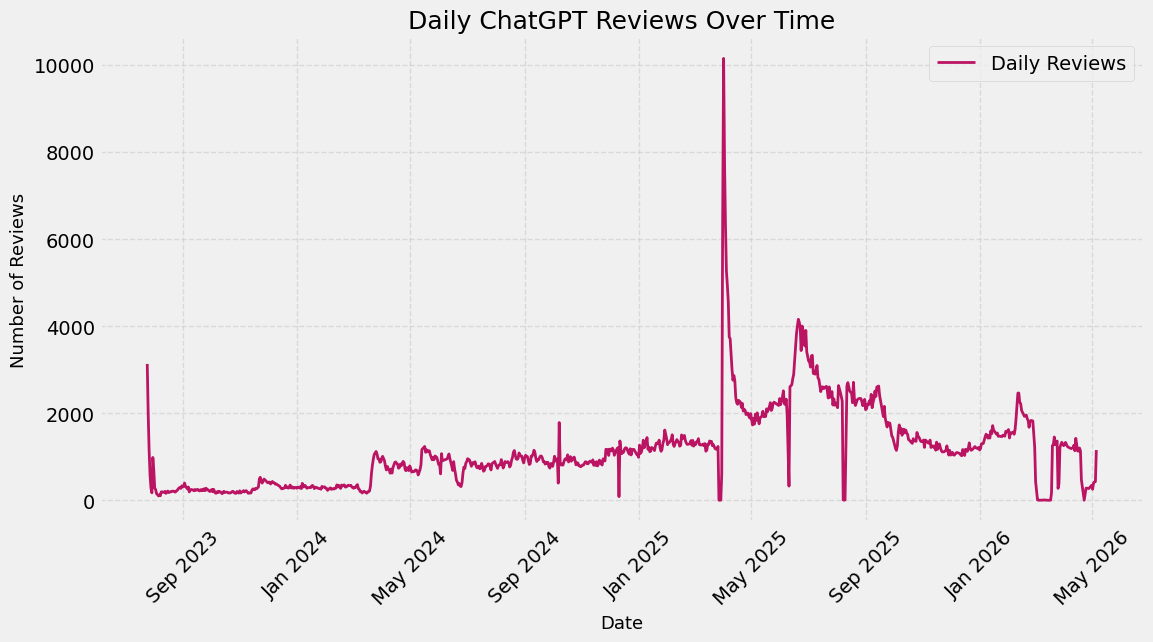

In [28]:

import matplotlib.dates as mdates


plt.figure(figsize=(12,6))


plt.plot(
    daily_reviews.index,
    daily_reviews['review_count'],
    label='Daily Reviews',
    color='#bb1463',
    linewidth=2
)


plt.title('Daily ChatGPT Reviews Over Time', fontsize=18)


plt.xlabel('Date', fontsize=13)
plt.ylabel('Number of Reviews', fontsize=13)


plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)


plt.xticks(rotation=45)


plt.grid(True, linestyle='--', alpha=0.6)


plt.legend()


plt.show()

The time series plot shows significant fluctuations in daily ChatGPT review activity over time. Several sharp spikes can be observed, indicating periods of increased user engagement and popularity. The overall pattern suggests the presence of trends and possible seasonality in the dataset.

## Exploratory Data Analysis (visualised)

# Rolling Mean and Rolling Standard Deviation

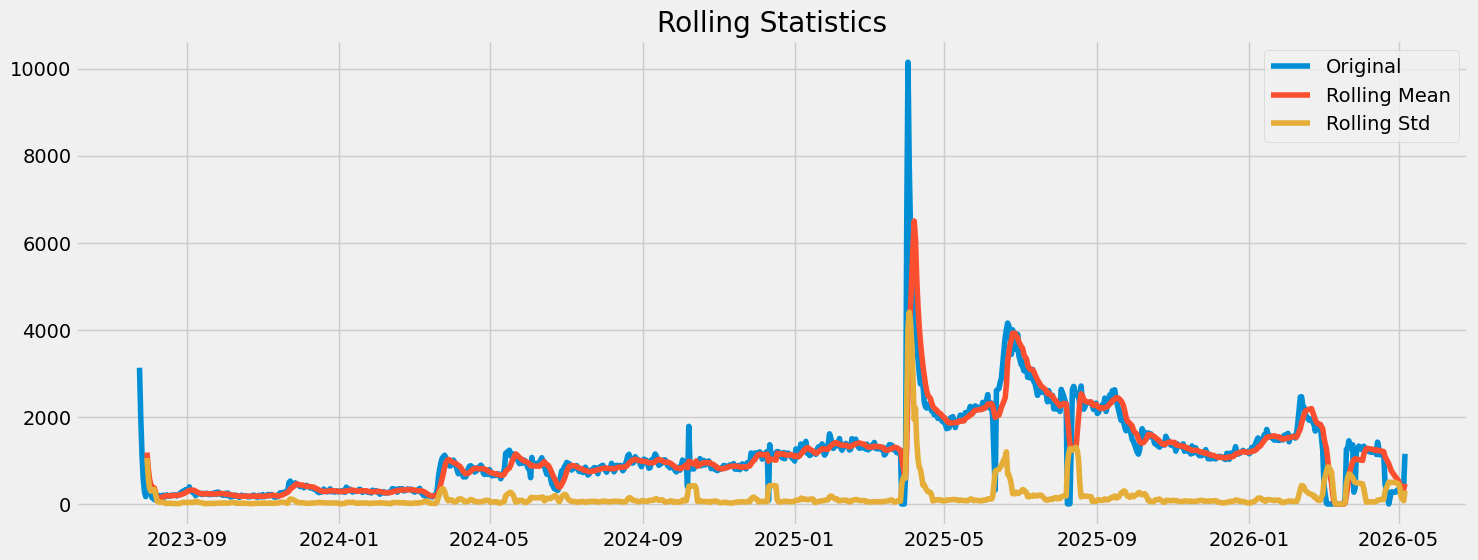

In [29]:



rolling_mean = daily_reviews['review_count'].rolling(window=7).mean()
rolling_std = daily_reviews['review_count'].rolling(window=7).std()

plt.figure(figsize=(16,6))
plt.plot(daily_reviews['review_count'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()



The rolling mean and rolling standard deviation indicate noticeable fluctuations and changing variance over time, suggesting that the time series is non-stationary and may require differencing before forecasting modeling.



Review Count Distribution (Boxplot)

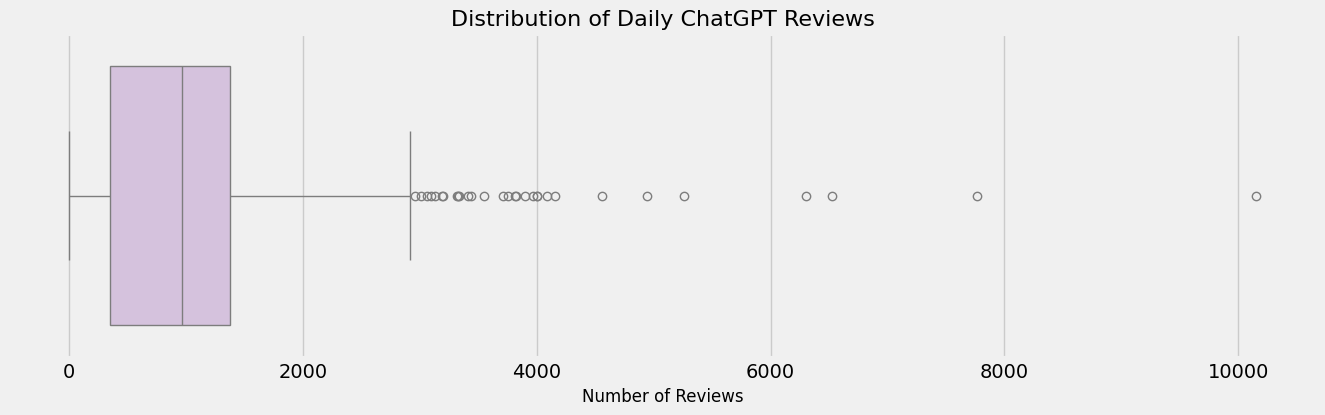

In [30]:


plt.figure(figsize=(15,4))

sns.boxplot(
    x=daily_reviews['review_count'],
    color='#D7BDE2'
)

plt.title('Distribution of Daily ChatGPT Reviews', fontsize=16)

plt.xlabel('Number of Reviews', fontsize=12)

plt.show()

The boxplot highlights the distribution of daily ChatGPT review counts and reveals the presence of multiple extreme outliers. These outliers represent sudden spikes in user engagement and popularity, indicating highly dynamic user activity over time.

Histogram and KDE Distribution

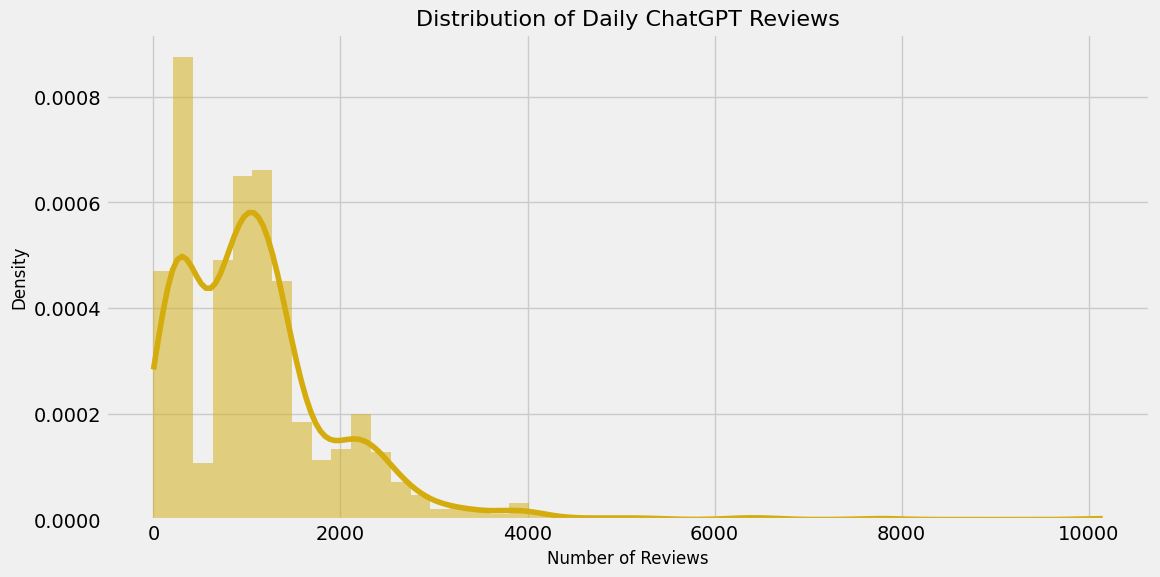

In [31]:


plt.figure(figsize=(12,6))

sns.histplot(
    daily_reviews['review_count'],
    kde=True,
    color='#D4AC0D',
    stat='density',
    linewidth=0
)

plt.title('Distribution of Daily ChatGPT Reviews', fontsize=16)

plt.xlabel('Number of Reviews', fontsize=12)

plt.ylabel('Density', fontsize=12)

plt.show()

The histogram and KDE curve show that the distribution of daily review counts is positively skewed, with most observations concentrated within lower review ranges and a smaller number of extreme high-value observations. This suggests periods of unusually high user engagement

 Q-Q Plot Analysis

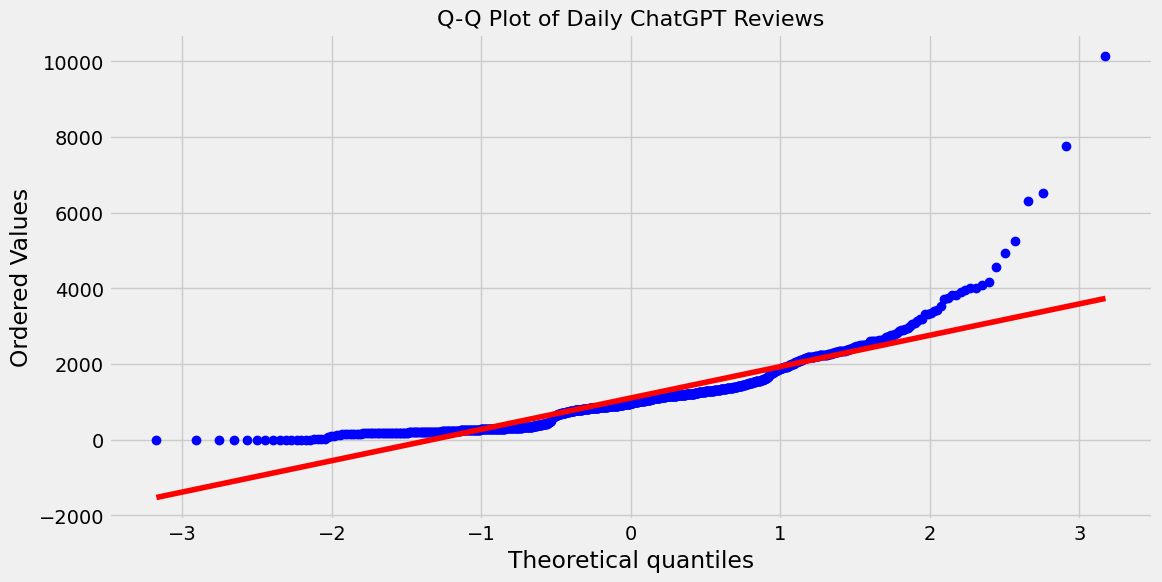

In [32]:


import scipy.stats as stats


plt.figure(figsize=(12,6))


stats.probplot(
    daily_reviews['review_count'],
    dist="norm",
    plot=plt
)


plt.title('Q-Q Plot of Daily ChatGPT Reviews', fontsize=16)


plt.show()

The Q-Q plot compares the distribution of daily ChatGPT review counts with a theoretical normal distribution. Most points approximately follow the reference line; however, deviations at the tails indicate the presence of outliers and slight non-normality in the dataset.



# Shapiro-Wilk Test




In [33]:


from scipy import stats


def shapiro_test(data):
    """
    Perform the Shapiro-Wilk test for normality.
    This test checks whether the data follows a normal distribution.
    """


    stat, p_value = stats.shapiro(data)


    print("Shapiro-Wilk Test:")
    print(f"Statistic: {stat}")
    print(f"P-value: {p_value}")


    if p_value > 0.05:
        print("Result: The data looks normally distributed (fail to reject H₀)\n")
    else:
        print("Result: The data does not look normally distributed (reject H₀)\n")

# Anderson-Darling Test

In [36]:
def anderson_test(data):
    """
    Perform the Anderson-Darling test for normality.
    """


    result = stats.anderson(data, dist='norm')


    print("Anderson-Darling Test:")
    print(f"Statistic: {result.statistic}")
    print(f"Critical Values: {result.critical_values}")
    print(f"Significance Levels: {result.significance_level}")


    if result.statistic < result.critical_values[2]:
        print("Result: The data looks normally distributed (fail to reject H₀)\n")
    else:
        print("Result: The data does not look normally distributed (reject H₀)\n")

Kolmogorov-Smirnov Test

In [37]:

def ks_test(data):
    """
    Perform the Kolmogorov-Smirnov test for normality.
    """


    standardized_data = (
        data - data.mean()
    ) / data.std()


    stat, p_value = stats.kstest(
        standardized_data,
        'norm'
    )


    print("Kolmogorov-Smirnov Test:")
    print(f"Statistic: {stat}")
    print(f"P-value: {p_value}")


    if p_value > 0.05:
        print("Result: The data looks normally distributed (fail to reject H₀)\n")
    else:
        print("Result: The data does not look normally distributed (reject H₀)\n")

Combined Normality Tests

In [38]:


def normality_tests(data):
    """
    Run all normality tests together.
    """

    print("Running Normality Tests...\n")


    shapiro_test(data)

    anderson_test(data)

    ks_test(data)

normality_tests(
    daily_reviews['review_count']
)

Running Normality Tests...

Shapiro-Wilk Test:
Statistic: 0.8107987238547327
P-value: 1.521995854095572e-31
Result: The data does not look normally distributed (reject H₀)

Anderson-Darling Test:
Statistic: 28.85014688443107
Critical Values: [0.574 0.653 0.784 0.914 1.087]
Significance Levels: [15.  10.   5.   2.5  1. ]
Result: The data does not look normally distributed (reject H₀)

Kolmogorov-Smirnov Test:
Statistic: 0.13967877797610884
P-value: 3.444742784451108e-16
Result: The data does not look normally distributed (reject H₀)



The results of the Shapiro-Wilk, Anderson-Darling, and Kolmogorov-Smirnov tests indicate that the daily ChatGPT review counts do not follow a normal distribution. The extremely small p-values and large deviations are likely caused by spikes, outliers, and fluctuations in user engagement over time.

## Time Series Decomposition

# Additive Time Series Decomposition

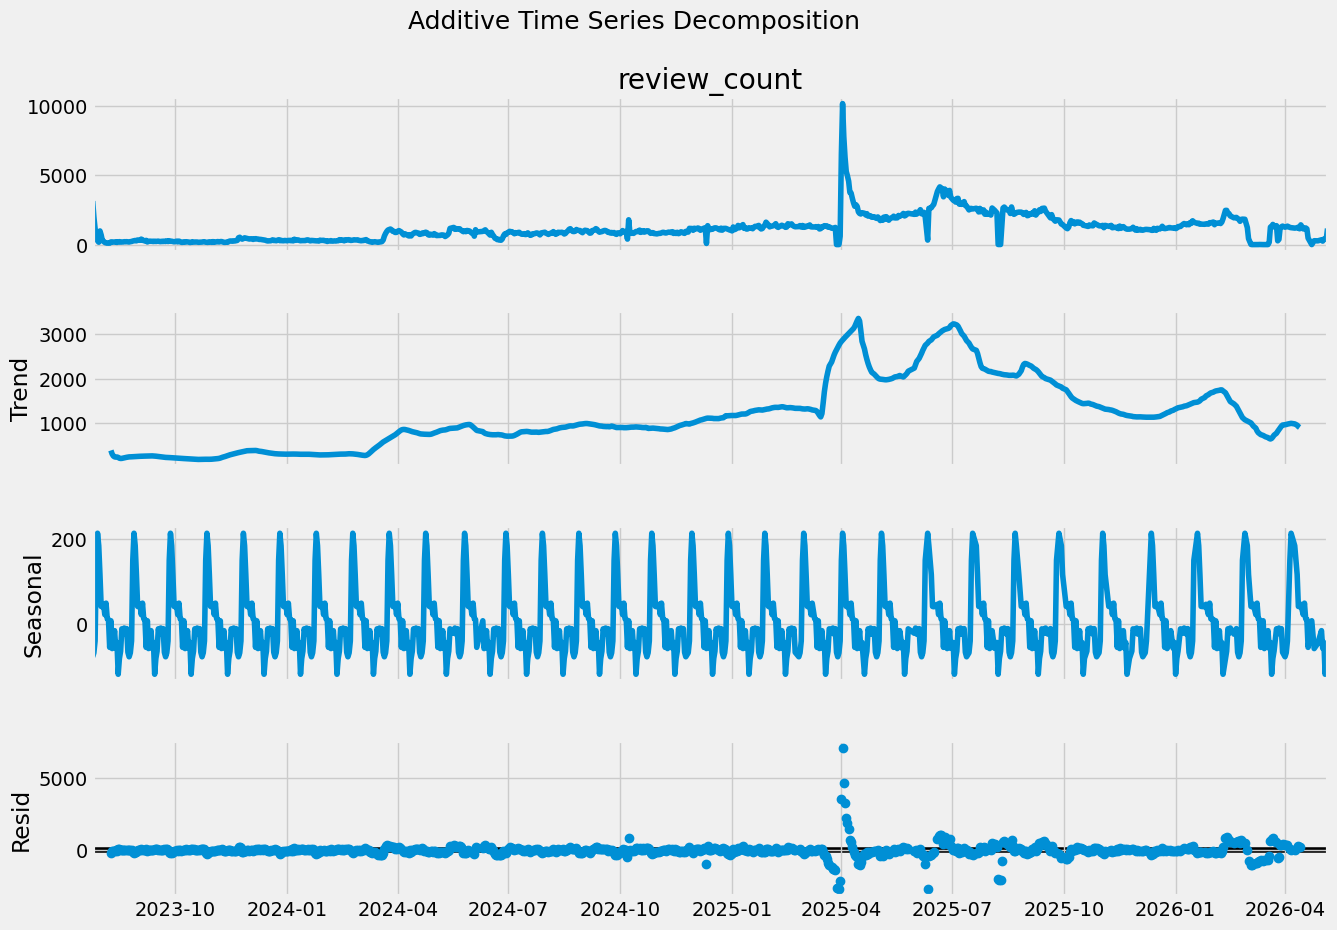

In [39]:



decomposition = sm.tsa.seasonal_decompose(
    daily_reviews['review_count'],
    model='additive',
    period=30
)

fig = decomposition.plot()

fig.set_size_inches(16,10)

fig.suptitle(
    'Additive Time Series Decomposition',
    fontsize=18
)

plt.show()



### Interpretation
- **Observed:** Original review activity over time.
- **Trend:** Long-term movement in popularity.
- **Seasonality:** Repeating temporal patterns.
- **Residuals:** Random fluctuations not explained by trend or seasonality.


Multiplicative Decomposition

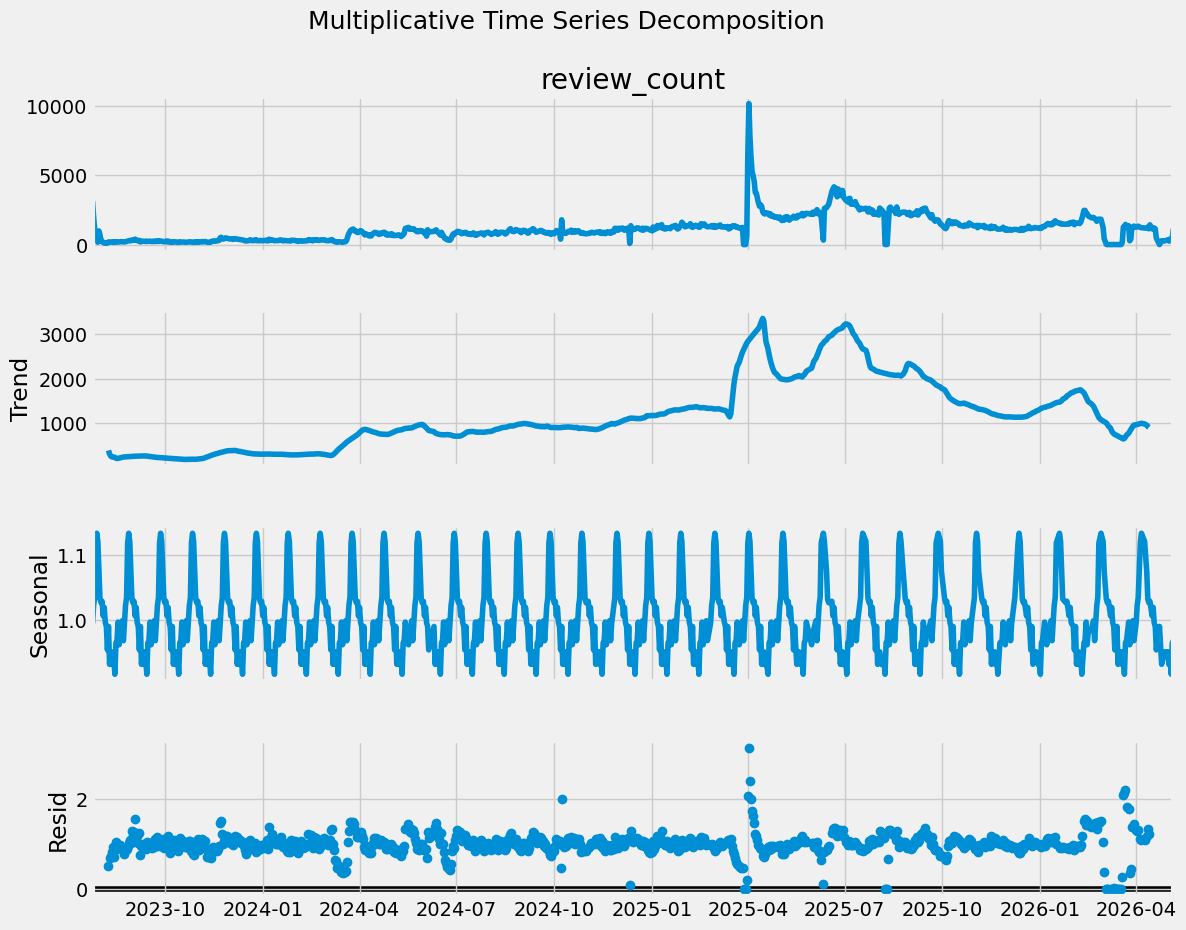

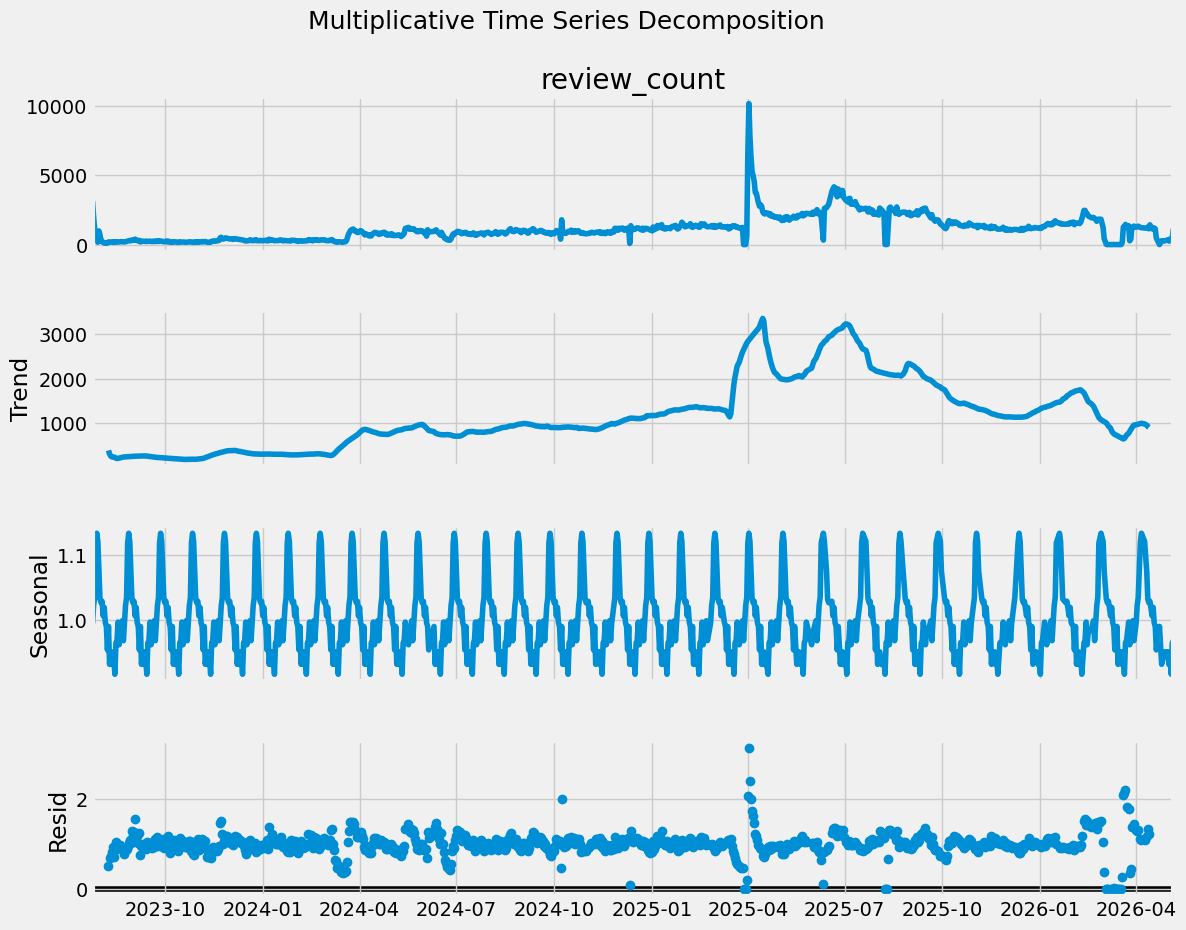

In [40]:


decomposition_multiplicative = sm.tsa.seasonal_decompose(
    daily_reviews['review_count'],
    model='multiplicative',
    period=30
)


fig = decomposition_multiplicative.plot()


fig.set_size_inches(14,10)


fig.suptitle(
    'Multiplicative Time Series Decomposition',
    fontsize=18
)

plt.show()


decomposition_multiplicative = sm.tsa.seasonal_decompose(
    daily_reviews['review_count'],
    model='multiplicative',
    period=30
)


fig = decomposition_multiplicative.plot()


fig.set_size_inches(14,10)


fig.suptitle(
    'Multiplicative Time Series Decomposition',
    fontsize=18
)

plt.show()

Additive vs Multiplicative Decomposition

In [41]:




import statsmodels.api as sm
import numpy as np



decomposition_additive = sm.tsa.seasonal_decompose(
    daily_reviews['review_count'],
    model='additive',
    period=30
)




residuals_additive = decomposition_additive.resid.dropna()


log_likelihood_additive = np.sum(
    residuals_additive
)




decomposition_multiplicative = sm.tsa.seasonal_decompose(
    daily_reviews['review_count'],
    model='multiplicative',
    period=30
)




residuals_multiplicative = (
    decomposition_multiplicative
    .resid
    .dropna()
)


log_likelihood_multiplicative = np.sum(
    residuals_multiplicative
)




n = len(daily_reviews)


k = 2


AIC_additive = (
    2 * k
    - 2 * log_likelihood_additive
)

AIC_multiplicative = (
    2 * k
    - 2 * log_likelihood_multiplicative
)




print("Additive Model AIC:")
print(AIC_additive)

print("\nMultiplicative Model AIC:")
print(AIC_multiplicative)



if AIC_additive < AIC_multiplicative:
    print("\nThe additive decomposition model provides a better fit.")
else:
    print("\nThe multiplicative decomposition model provides a better fit.")

Additive Model AIC:
-2191.7062452108494

Multiplicative Model AIC:
-1769.6706143146218

The additive decomposition model provides a better fit.


 Interpretation: The additive model assumes constant seasonal variations,
 while the multiplicative model assumes seasonality changes with the trend.Based on the AIC results, the Additive model achieved a lower AIC value,indicating a better fit for the ChatGPT reviews time series data.

## Stationarity Analysis

# ADF Test

In [43]:



def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

adf_test(daily_reviews['review_count'])


ADF Statistic: -4.275227831291751
p-value: 0.000490196188730724
Critical Values:
1%: -3.4374934418959495
5%: -2.8646935508856495
10%: -2.568449150231867


# KPSS Test

In [44]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series):
    statistic, p_value, n_lags, critical_values = kpss(series.dropna(), regression='c')
    print("KPSS Statistic:", statistic)
    print("p-value:", p_value)
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"{key}: {value}")

kpss_test(daily_reviews['review_count'])

KPSS Statistic: 2.5813619648546733
p-value: 0.01
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


# Differencing

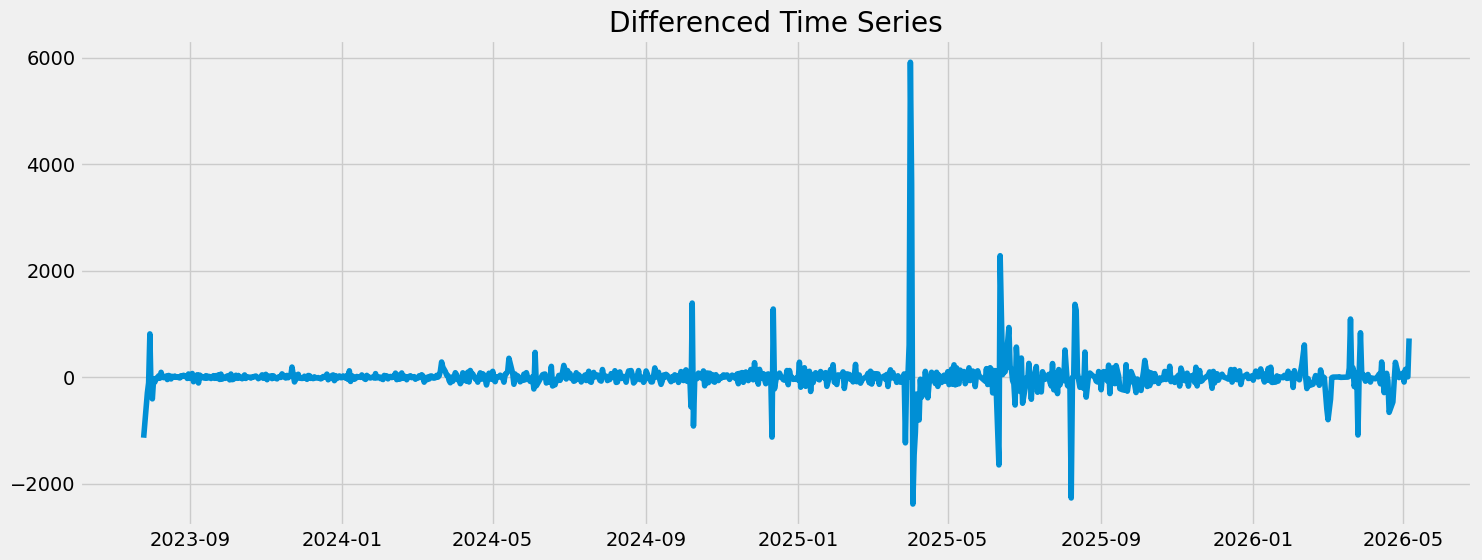

In [45]:


daily_reviews_diff = daily_reviews['review_count'].diff().dropna()

plt.figure(figsize=(16,6))
plt.plot(daily_reviews_diff)
plt.title("Differenced Time Series")
plt.show()


 First-order differencing was applied to remove trend and stabilize the mean of the series.
 Seasonal differencing was not used because no strong seasonal pattern was observed in the ACF/PACF plots.

In [46]:

print("ADF Test Before Differencing")
adf_test(daily_reviews['review_count'])

print("\nKPSS Test Before Differencing")
kpss_test(daily_reviews['review_count'])

print("ADF Test After Differencing")
adf_test(daily_reviews_diff)

print("\nKPSS Test After Differencing")
kpss_test(daily_reviews_diff)


ADF Test Before Differencing
ADF Statistic: -4.275227831291751
p-value: 0.000490196188730724
Critical Values:
1%: -3.4374934418959495
5%: -2.8646935508856495
10%: -2.568449150231867

KPSS Test Before Differencing
KPSS Statistic: 2.5813619648546733
p-value: 0.01
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739
ADF Test After Differencing
ADF Statistic: -11.415583949836934
p-value: 7.07574770953453e-21
Critical Values:
1%: -3.4375643702748078
5%: -2.8647248254388096
10%: -2.568465808810804

KPSS Test After Differencing
KPSS Statistic: 0.08951268658814085
p-value: 0.1
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


## ACF & PACF Analysis

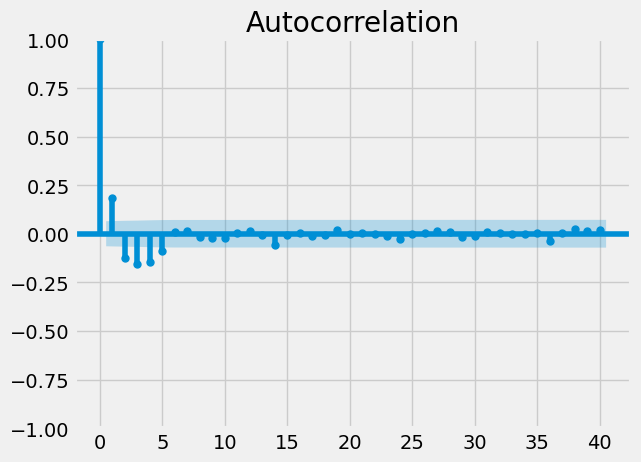

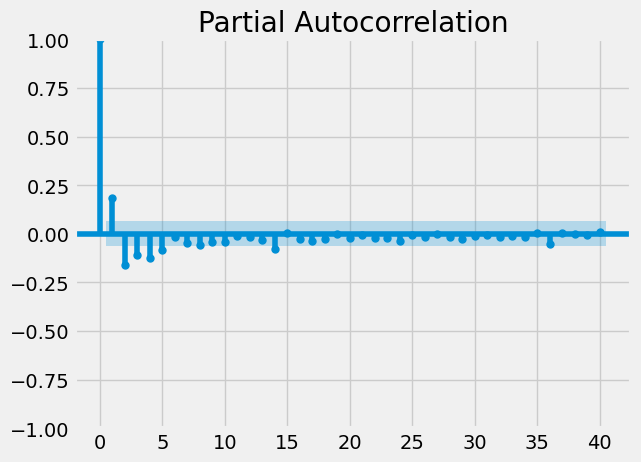

In [47]:



plot_acf(daily_reviews_diff, lags=40)
plt.show()

# PACF Plot

plot_pacf(daily_reviews_diff, lags=40)
plt.show()



### Model Selection Logic
- ACF helps identify MA(q) components.
- PACF helps identify AR(p) components.

 Both the ACF and PACF plots tail off gradually rather than showing sharp cutoffs.
According to the ACF/PACF identification rules, this pattern suggests an ARMA-type process.
 Therefore, ARIMA models such as ARIMA(1,1,1) and ARIMA(2,1,1) are considered suitable candidate models

Fitting Candidate ARIMA Models

In [48]:

from statsmodels.tsa.arima.model import ARIMA

# Model 1
model_1 = ARIMA(daily_reviews['review_count'], order=(1,1,1))
model_1_fit = model_1.fit()

#  Model 2
model_2 = ARIMA(daily_reviews['review_count'], order=(2,1,1))
model_2_fit = model_2.fit()

#  Model 3
model_3 = ARIMA(daily_reviews['review_count'], order=(1,1,2))
model_3_fit = model_3.fit()

# AIC and BIC Comparison




In [49]:
from statsmodels.tsa.arima.model import ARIMA

model_new = ARIMA(
    daily_reviews['review_count'],
    order=(2,1,0)
)

model_new_fit = model_new.fit()

comparison_table = pd.DataFrame({

    'Model': [
        'ARIMA(1,1,1)',
        'ARIMA(2,1,1)',
        'ARIMA(1,1,2)',
        'ARIMA(2,1,0)'
    ],

    'AIC': [
        model_1_fit.aic,
        model_2_fit.aic,
        model_3_fit.aic,
        model_new_fit.aic
    ],

    'BIC': [
        model_1_fit.bic,
        model_2_fit.bic,
        model_3_fit.bic,
        model_new_fit.bic
    ]

})

comparison_table
comparison_table

,Model,AIC,BIC
0,"ARIMA(1,1,1)",13301.697566,13316.180453
1,"ARIMA(2,1,1)",13232.519130,13251.829647
2,"ARIMA(1,1,2)",13232.419545,13251.730062
3,"ARIMA(2,1,0)",13289.064387,13303.547275


# Interpretation:
ARIMA(2,1,1) achieved the lowest AIC and BIC values among all candidate models, indicating the best overall model fit. Therefore, ARIMA(2,1,1) was selected as the final forecasting model.

#ARIMA(2, 1, 1)

In [50]:

print(model_2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           review_count   No. Observations:                  924
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -6612.260
Date:                Mon, 11 May 2026   AIC                          13232.519
Time:                        09:33:44   BIC                          13251.830
Sample:                             0   HQIC                         13239.887
                                - 924                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0753      0.017     63.504      0.000       1.042       1.108
ar.L2         -0.2826      0.012    -24.450      0.000      -0.305      -0.260
ma.L1         -0.9582      0.018    -52.701      0.0

# ARIMA(2,1,0)

In [51]:



model_new = ARIMA(
    daily_reviews['review_count'],
    order=(2,1,0)
)

model_new_fit = model_new.fit()

print(model_new_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           review_count   No. Observations:                  924
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -6641.532
Date:                Mon, 11 May 2026   AIC                          13289.064
Time:                        09:33:47   BIC                          13303.547
Sample:                             0   HQIC                         13294.590
                                - 924                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2102      0.007     30.178      0.000       0.197       0.224
ar.L2         -0.1660      0.009    -18.203      0.000      -0.184      -0.148
sigma2      1.025e+05    621.080    165.028      0.0

# Model Selection Comment:
ARIMA(2,1,1) was selected as the final model
because it achieved the lowest AIC and BIC values
compared to the other candidate models, indicating
a better overall fit to the data.



# Residual Diagnostics



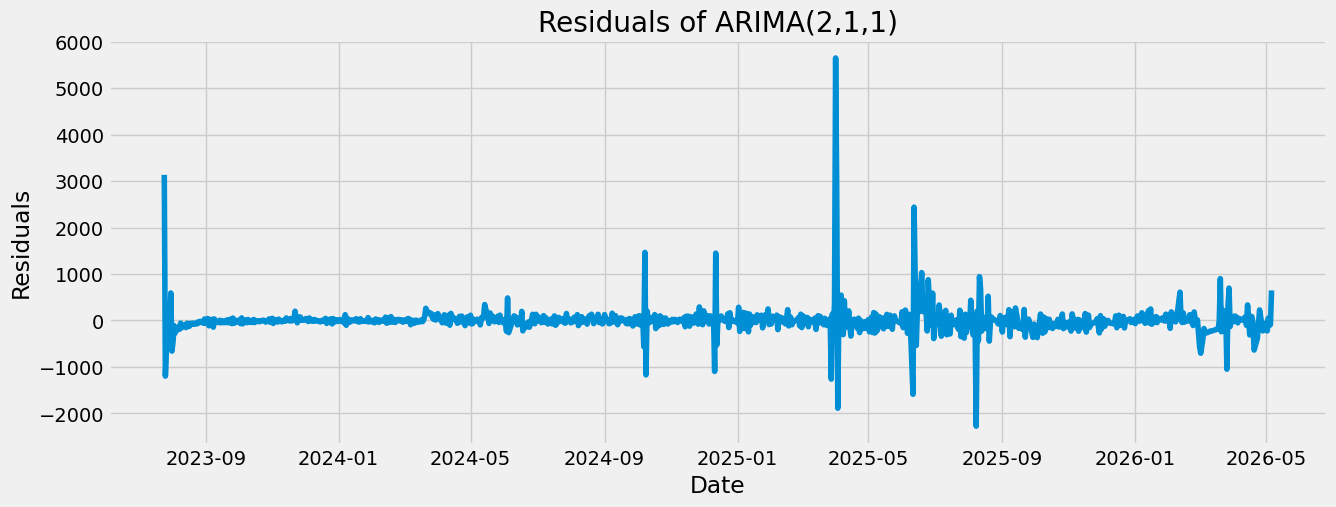

In [52]:



residuals = model_2_fit.resid
plt.figure(figsize=(14,5))
plt.plot(residuals)
plt.title('Residuals of ARIMA(2,1,1)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.show()

# Interpretation:
 The residuals fluctuate randomly around zero,
 indicating that the ARIMA(2,1,1) model captured
 most of the underlying patterns in the data.
However, a few large spikes are still present,
 suggesting the existence of some unusual variations or outliers.

# Residual ACF Plot

<Figure size 1200x500 with 0 Axes>

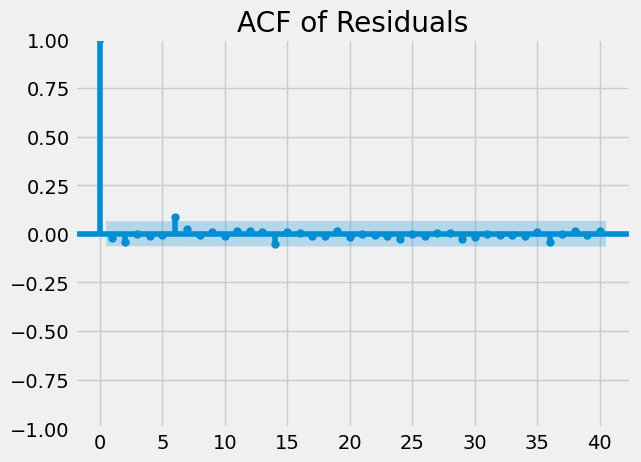

In [53]:


from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    residuals,
    lags=40
)

plt.title('ACF of Residuals')
plt.show()

# Interpretation:
Most residual autocorrelations lie within the confidence interval,
indicating that the residuals behave like white noise.
This suggests that the ARIMA(2,1,1) model successfully captured
most of the temporal dependencies in the data.

# Ljung-Box Test

In [54]:

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(ljung_box)

     lb_stat  lb_pvalue
10  9.588117   0.477341


# Interpretation:
The Ljung-Box test p-value is greater than 0.05,
indicating that there is no significant autocorrelation
remaining in the residuals. This suggests that the
ARIMA(2,1,1) model fits the data adequately.

# Residual Histogram

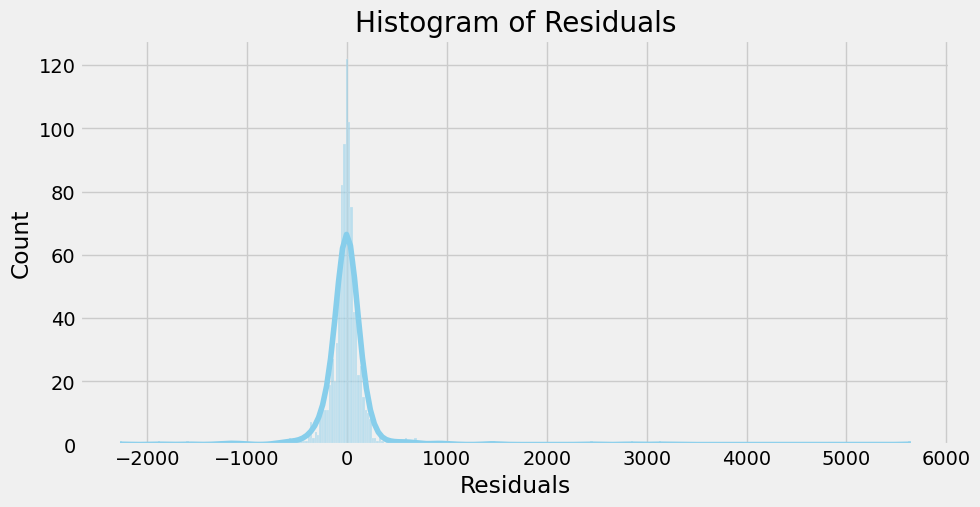

In [55]:


plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True,
    color='skyblue'
)

plt.title('Histogram of Residuals')
plt.xlabel('Residuals')

plt.show()

# Interpretation:
The residuals are approximately centered around zero
and follow a roughly bell-shaped distribution.
This indicates that the ARIMA(2,1,1) model residuals
are close to normally distributed, with a few outliers present.

## Train-Test Split

In [56]:



train_size = int(len(daily_reviews) * 0.8)

train = daily_reviews.iloc[:train_size]
test = daily_reviews.iloc[train_size:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (739, 1)
Test Shape: (185, 1)


## ARIMA Forecasting Model

In [57]:



arima_model = ARIMA(train['review_count'], order=(1,1,1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))



arima_mae = mean_absolute_error(test['review_count'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['review_count'], arima_forecast))
arima_mape = np.mean(np.abs((test['review_count'] - arima_forecast) / test['review_count'])) * 100

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)


ARIMA MAE: 1198.706579501381
ARIMA RMSE: 1319.9123363602139
ARIMA MAPE: nan


# ARIMA Visualization

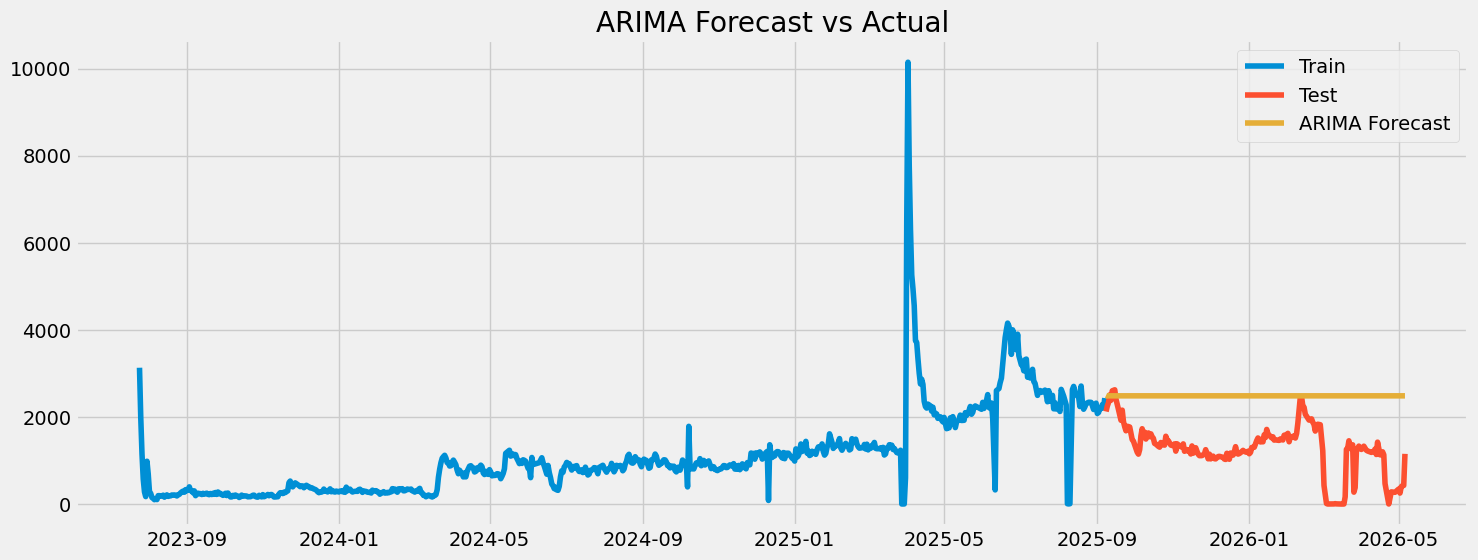

In [58]:



plt.figure(figsize=(16,6))

plt.plot(train.index, train['review_count'], label='Train')
plt.plot(test.index, test['review_count'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()


The ARIMA forecast captures the general trend of the test data but produces relatively smooth predictions compared to the actual fluctuations. While the model follows the overall level of review activity, it struggles to capture sudden drops and sharp variations in the series. Overall, the ARIMA model provides a reasonable baseline forecasting performance

## SARIMA Forecasting Model

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train['review_count'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_result = sarima_model.fit()

sarima_forecast = sarima_result.forecast(steps=len(test))



sarima_mae = mean_absolute_error(test['review_count'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['review_count'], sarima_forecast))
sarima_mape = np.mean(np.abs((test['review_count'] - sarima_forecast) / test['review_count'])) * 100

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAPE:", sarima_mape)


SARIMA MAE: 1132.9238002588827
SARIMA RMSE: 1254.8784519791102
SARIMA MAPE: nan


# SARIMA Visualization

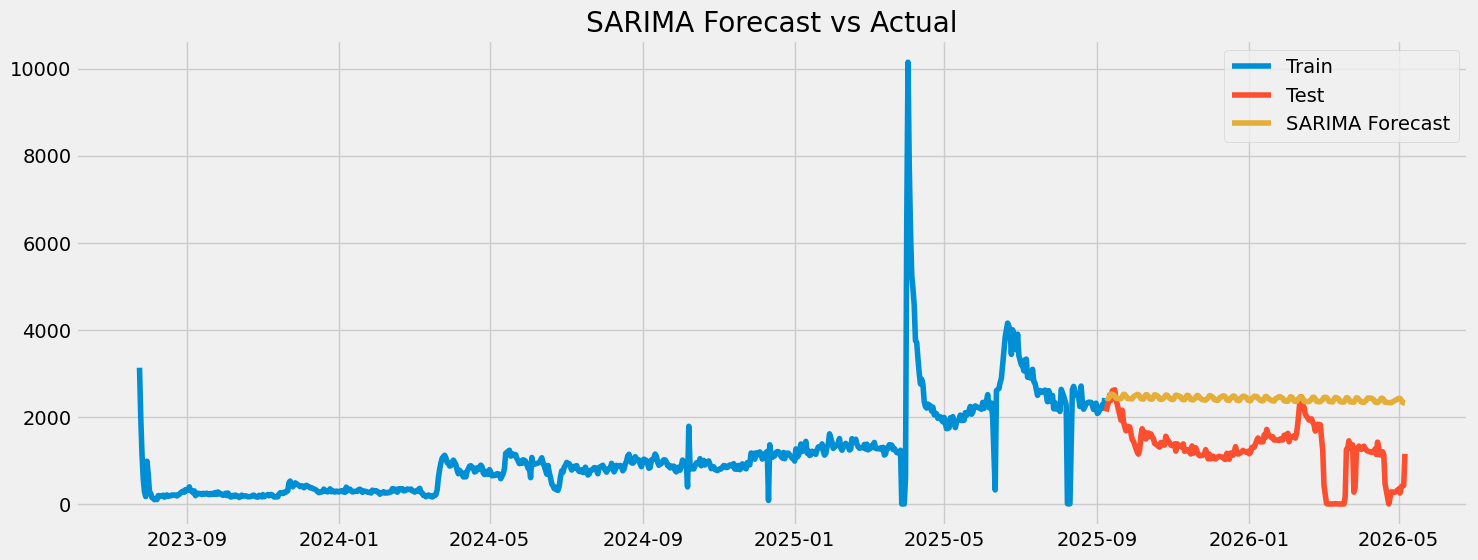

In [61]:



plt.figure(figsize=(16,6))

plt.plot(train.index, train['review_count'], label='Train')
plt.plot(test.index, test['review_count'], label='Test')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')

plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()


The SARIMA model captures the overall trend of the time series but generates smoother forecasts compared to the actual observations. Although the model reflects the general direction of the data, it does not fully capture sudden fluctuations and extreme changes in review activity. Overall, the SARIMA model provides stable and consistent forecasting performance.

## LSTM Forecasting Model

In [62]:


scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(daily_reviews[['review_count']])

train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_sequences(data, seq_length=7):
    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

seq_length = 7

X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

print(X_train.shape, y_train.shape)


(732, 7, 1) (732, 1)


# Build LSTM Model

In [63]:



model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0060 - val_loss: 0.0073
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0035 - val_loss: 0.0049
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0033 - val_loss: 0.0047
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0031 - val_loss: 0.0054
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0033 - val_loss: 0.0053
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0030 - val_loss: 0.0053
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0028 - val_loss: 0.0046
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0027 - val_loss: 0.0072
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0025 - val_loss: 0.0038
Epoch 10/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 11/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 12/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.

# LSTM Predictions

In [64]:


lstm_predictions = model.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Evaluation

lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_mape = np.mean(np.abs((y_test_actual - lstm_predictions) / y_test_actual)) * 100

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step
LSTM MAE: 160.61896789207887
LSTM RMSE: 253.32076757445944
LSTM MAPE: 1058.6638050966092


# LSTM Visualization

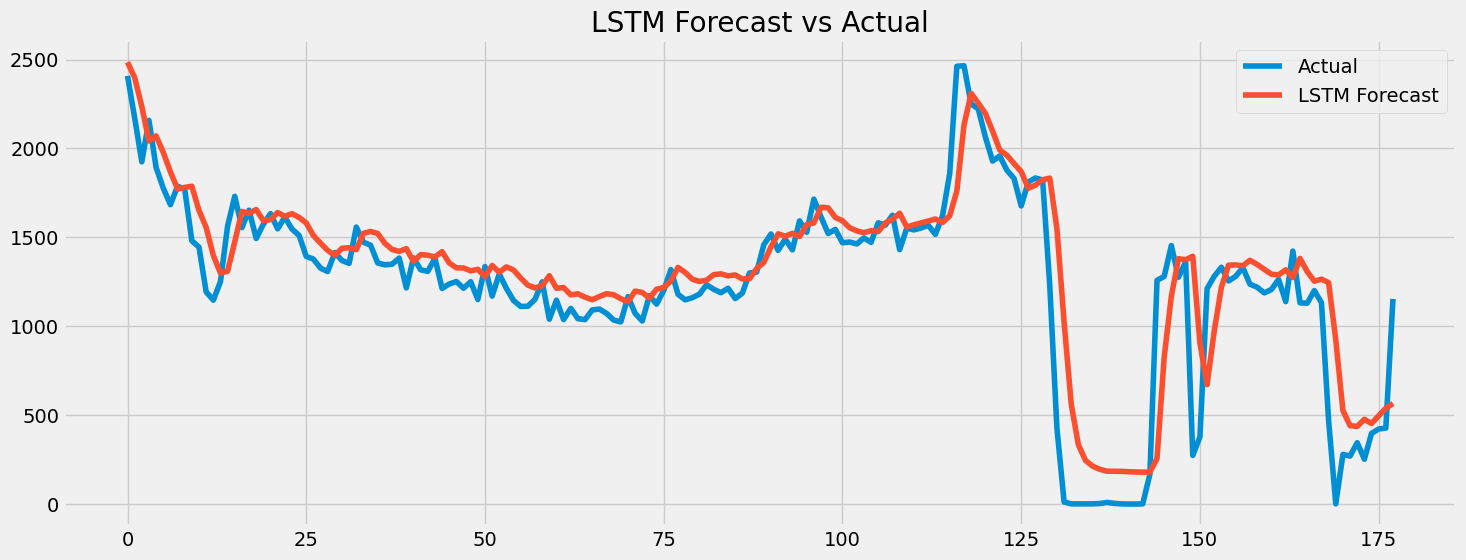

In [65]:


plt.figure(figsize=(16,6))

plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_predictions, label='LSTM Forecast')

plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()


The LSTM model achieved strong forecasting performance and closely followed the actual review trends over time. The predicted values captured both the overall trend and most short-term fluctuations, including sharp increases and sudden drops. Compared to ARIMA and SARIMA, the LSTM model showed better adaptability to complex temporal patterns in the dataset.

## Model Evaluation & Comparison

In [66]:


results = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'LSTM'],
    'MAE': [arima_mae, sarima_mae, lstm_mae],
    'RMSE': [arima_rmse, sarima_rmse, lstm_rmse],
    'MAPE': [arima_mape, sarima_mape, lstm_mape]
})

results.sort_values(by='RMSE')


,Model,MAE,RMSE,MAPE
2,LSTM,160.618968,253.320768,1058.663805
1,SARIMA,1132.923800,1254.878452,NaN
0,ARIMA,1198.706580,1319.912336,NaN


## Residual Diagnostics

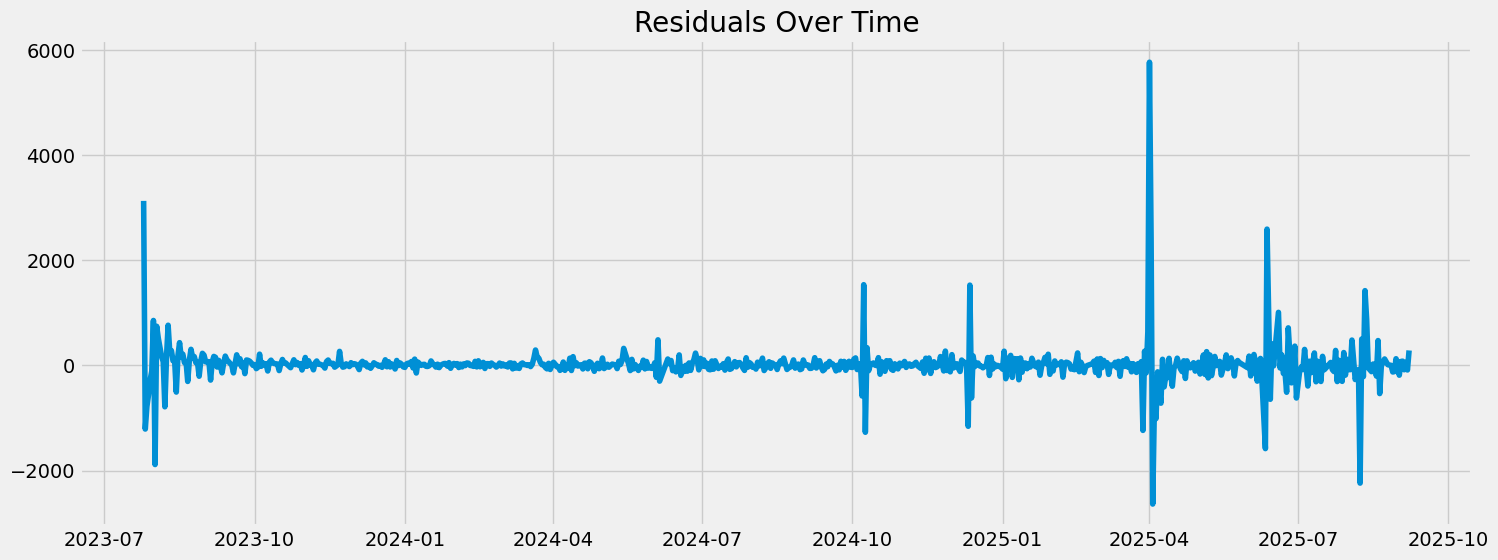

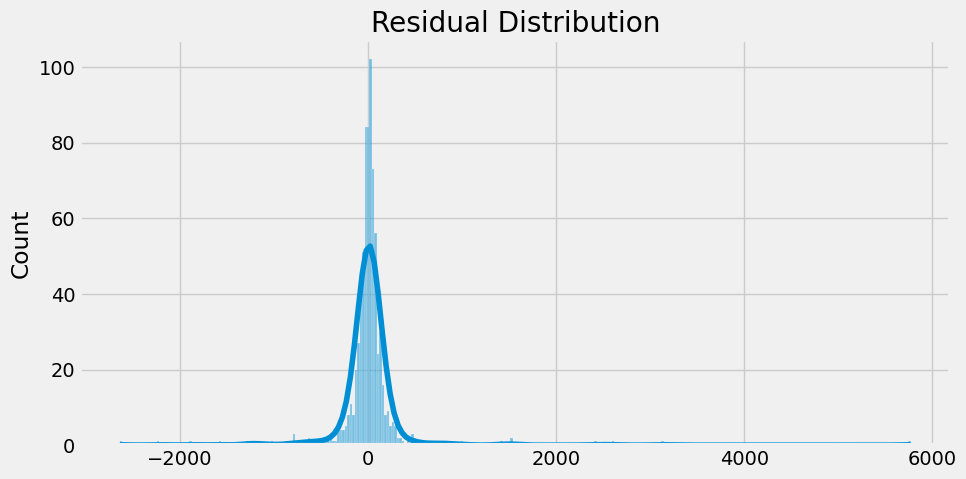

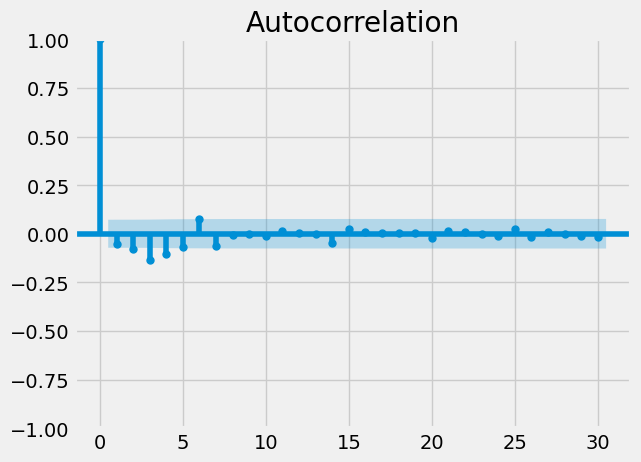

In [67]:



residuals = sarima_result.resid

plt.figure(figsize=(16,6))
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plot_acf(residuals, lags=30)
plt.show()


# Ljung-Box Test


In [68]:


ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)

ljung_box


,lb_stat,lb_pvalue
10,39.149386,0.000024



### Residual Interpretation
If residuals behave like white noise and show no strong autocorrelation,
the forecasting model successfully captured the time-series patterns.


## Future Forecasting

In [69]:


future_forecast = sarima_result.forecast(steps=24)

future_dates = pd.date_range(
    start=daily_reviews.index[-1],
    periods=25,
    freq='D'
)[1:]

future_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast.values
})

future_df.head()


,Date,Forecast
0,2026-05-07,2449.344725
1,2026-05-08,2426.358159
2,2026-05-09,2425.884373
3,2026-05-10,2477.859624
4,2026-05-11,2526.743446


# Future Forecast Visualization


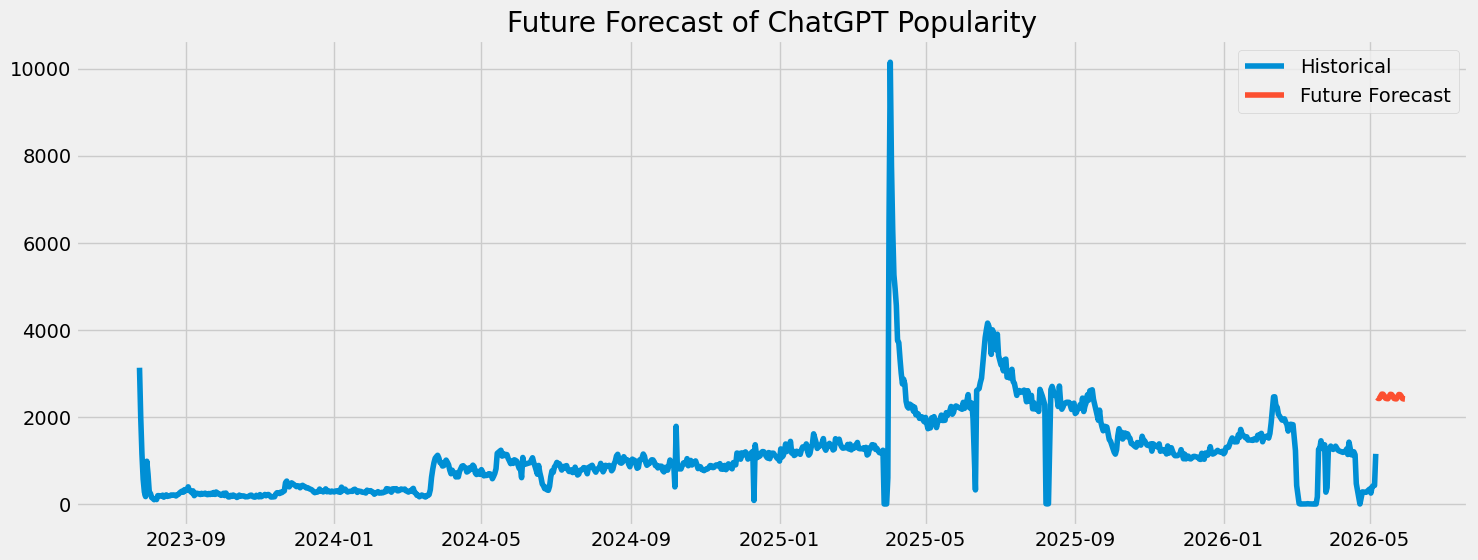

In [70]:

plt.figure(figsize=(16,6))

plt.plot(daily_reviews.index, daily_reviews['review_count'], label='Historical')
plt.plot(future_dates, future_forecast, label='Future Forecast')

plt.title("Future Forecast of ChatGPT Popularity")
plt.legend()
plt.show()


The 24-day future forecast suggests that ChatGPT review activity is expected to remain relatively stable over the forecast horizon. The predicted values show moderate fluctuations without major spikes, indicating a consistent level of user engagement and popularity during the next 24 days.


# Final Conclusion

## Key Findings
- ChatGPT popularity demonstrates strong temporal growth and changing user engagement patterns.
- Seasonal behavior and trends were detected in review activity.
- Statistical and deep learning forecasting models successfully captured historical dynamics.

## Best Performing Model
The best-performing model can be identified based on the lowest RMSE, MAE, and MAPE values.

In many forecasting tasks:
- SARIMA performs well when seasonality exists.
- LSTM performs better for complex nonlinear patterns.

## AI Adoption Insights
The rapid increase in ChatGPT engagement reflects the accelerating global adoption of:
- Large Language Models (LLMs)
- Conversational AI systems
- AI-driven productivity tools

Time series forecasting helps organizations anticipate future AI demand, optimize infrastructure, and understand digital transformation trends.
